## Part 3: Insight Generation

---

### Data Loading and Inspection

Before conducting the analysis, all five datasets were loaded into the notebook and inspected for structure, completeness, and join keys.

In [ ]:
import pandas as pd 
import os
import numpy as np
import matplotlib.pyplot as plt


base_dir = os.path.dirname(os.getcwd())
voice_ai_data_dir = os.path.join(base_dir, 'irembo_assessment', 'full_data')
voice_ai_data_dir = voice_ai_data_dir.replace('\\', '/')

def load_voice_ai_data(file_name: str) -> pd.DataFrame:
    """
    This function loads a CSV file from the voice_ai_data_dir and returns it as a pandas DataFrame.

    Args:
        file_name (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: The loaded data as a pandas DataFrame.
    """
    try:
        if not isinstance(file_name, str):
            raise ValueError("file_name must be a string")
        
        file_path = os.path.join(voice_ai_data_dir, file_name)
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        raise Exception({
            "status": "error",
            "message": "An error occurred while loading the data.",
            "error": str(e)
        })

users_df = load_voice_ai_data('users.csv')
applications_df = load_voice_ai_data('applications.csv')
voice_ai_metrics_df = load_voice_ai_data('voice_ai_metrics.csv')
voice_sessions_df = load_voice_ai_data('voice_sessions.csv')
voice_turns_df = load_voice_ai_data('voice_turns.csv')

In [3]:
voice_sessions_df

,session_id,user_id,channel,language,total_duration_sec,total_turns,final_outcome,transfer_reason,created_at
0,S2000,U1303,voice,KINYARWANDA,173,11,abandoned,system,2025-02-17
1,S2001,U1449,voice,KINYARWANDA,150,4,completed,NaN,2025-02-20
2,S2002,U1453,voice,KINYARWANDA,128,11,transferred,NaN,2025-04-07
3,S2003,U1411,voice,KINYARWANDA,63,14,completed,NaN,2025-04-29
4,S2004,U1116,voice,KINYARWANDA,38,10,abandoned,NaN,2025-04-05
...,...,...,...,...,...,...,...,...,...
1195,S3195,U1416,voice,KINYARWANDA,88,14,abandoned,NaN,2025-04-01
1196,S3196,U1219,voice,KINYARWANDA,48,12,completed,NaN,2025-03-13
1197,S3197,U1128,voice,KINYARWANDA,245,3,completed,NaN,2025-03-15
1198,S3198,U1007,voice,KINYARWANDA,25,10,completed,NaN,2025-03-13


In [50]:
users_df

,user_id,region,disability_flag,first_time_digital_user
0,U1000,rural,no,yes
1,U1001,urban,no,no
2,U1002,urban,no,no
3,U1003,rural,no,no
4,U1004,rural,no,no
...,...,...,...,...
495,U1495,rural,yes,no
496,U1496,rural,no,no
497,U1497,rural,no,no
498,U1498,urban,no,yes


In [51]:
applications_df

,application_id,session_id,user_id,service_code,channel,status,time_to_submit_sec,submitted_at
0,A4000,S2717,U1355,ID_REPLACEMENT,web,completed,517,2025-04-04
1,A4001,S2143,U1486,LAND,web,completed,263,2025-04-29
2,A4002,S2332,U1139,DL,voice,completed,606,2025-01-22
3,A4003,S2372,U1268,ID_REPLACEMENT,voice,abandoned,392,2025-04-14
4,A4004,S3198,U1139,DL,ussd,failed,351,2025-01-15
...,...,...,...,...,...,...,...,...
895,A4895,S2500,U1034,ID_REPLACEMENT,voice,failed,540,2025-02-07
896,A4896,S2796,U1438,ID_REPLACEMENT,web,failed,492,2025-04-23
897,A4897,S2909,U1225,ID_REPLACEMENT,voice,completed,978,2025-04-04
898,A4898,S2753,U1032,LAND,web,completed,522,2025-04-23


In [52]:
voice_ai_metrics_df

,session_id,avg_asr_confidence,avg_intent_confidence,misunderstanding_rate,silence_rate,recovery_success,escalation_flag
0,S2000,0.711667,0.846667,0.333333,0.166667,no,no
1,S2001,0.803333,0.670000,0.000000,0.000000,yes,no
2,S2002,0.772000,0.850000,0.400000,0.000000,no,no
3,S2003,0.737500,0.702500,0.250000,0.000000,no,no
4,S2004,0.903333,0.686667,0.333333,0.000000,no,no
...,...,...,...,...,...,...,...
1191,S3195,0.751111,0.763333,0.111111,0.333333,yes,yes
1192,S3196,0.690000,0.792857,0.285714,0.571429,no,yes
1193,S3197,0.836667,0.696667,0.166667,0.333333,yes,yes
1194,S3198,0.671667,0.738333,0.500000,0.166667,no,no


In [53]:
voice_turns_df

,turn_id,session_id,turn_number,speaker,detected_intent,intent_confidence,asr_confidence,error_type,turn_duration_sec,created_at
0,T3000,S2840,6,system,repeat,0.61,0.83,misunderstanding,10,2025-02-21
1,T3001,S3094,8,user,start_application,0.59,0.60,NaN,8,2025-02-19
2,T3002,S2589,10,user,repeat,0.57,0.94,NaN,8,2025-03-03
3,T3003,S3153,14,system,start_application,0.62,0.67,NaN,3,2025-02-24
4,T3004,S2888,4,system,service_lookup,0.89,0.29,silence,12,2025-02-02
...,...,...,...,...,...,...,...,...,...,...
6495,T9495,S2845,6,system,start_application,0.86,0.83,NaN,2,2025-03-07
6496,T9496,S2694,4,user,start_application,0.81,0.63,NaN,12,2025-01-13
6497,T9497,S2549,4,user,service_lookup,0.92,0.71,NaN,4,2025-01-31
6498,T9498,S2928,3,user,repeat,0.75,0.84,NaN,10,2025-02-09


---

### (3a) Identify the Top Three Friction Points in Voice AI Interactions

#### Solution

---

##### Understanding Friction in Voice AI Interactions

In the context of Voice AI–driven public service delivery, **friction** refers to points within a voice session where the interaction breaks down or requires increased user effort to progress. These breakpoints often lead to inefficient conversations, user frustration, or failure to complete the intended service outcome.

In practice, friction manifests through behaviors such as repeated prompts, prolonged interactions, abandonment of sessions, or the inability of the system to correctly understand or recover from user input.

Operationally, friction can be observed through a combination of **error signals** and **session outcomes**, rather than a single metric.

---

### Observable Signals of Friction

Using the available datasets, friction can be measured at two levels:

#### Turn-Level Indicators

These capture issues occurring within individual conversational turns and include:

* `error_type` (e.g., silence, misunderstanding)
* `asr_confidence` (speech recognition quality)
* `intent_confidence` (accuracy of intent classification)
* Repeated or corrective intents such as `repeat`

#### Session-Level Indicators

These reflect the cumulative impact of turn-level issues across an entire interaction and include:

* `misunderstanding_rate`
* `silence_rate`
* `avg_asr_confidence`
* `avg_intent_confidence`
* `total_duration_sec`
* `total_turns`
* `final_outcome` (completed vs abandoned)

By connecting turn-level indicators to session-level outcomes, we can identify which issues most consistently degrade Voice AI effectiveness.

---


#### Step 1: Identify Frequency of Silence and Misunderstanding Errors

The first step is to understand **which error types occur most frequently** during Voice AI interactions. High-frequency errors are strong candidates for systemic friction points.


In [8]:
error_counts = (
    voice_turns_df
    .dropna(subset=["error_type"])
    .groupby("error_type")
    .agg(error_count=("error_type", "count"))
    .sort_values("error_count", ascending=False)
)

error_counts['error_percent'] = (
    error_counts['error_count'] / error_counts['error_count'].sum() * 100
).round(2)

error_counts = error_counts.reset_index()
error_counts


,error_type,error_count,error_percent
0,misunderstanding,1284,49.67
1,silence,991,38.34
2,noise,310,11.99


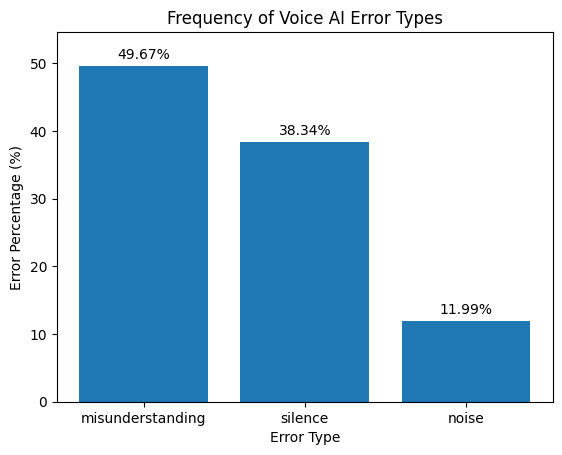

In [10]:
fig, ax = plt.subplots()

bars = ax.bar(
    error_counts["error_type"],
    error_counts["error_percent"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Frequency of Voice AI Error Types")
ax.set_xlabel("Error Type")
ax.set_ylabel("Error Percentage (%)")
ax.set_ylim(0, error_counts["error_percent"].max() * 1.1)

plt.show()


The analysis shows that **misunderstandings** and **silence-related errors** dominate the error distribution, and it accounts for approximately **49.7%** and **38.3%** of all recorded errors respectively.

This concentration indicates that the majority of conversational breakdowns stem from failures in understanding user speech or responding appropriately when no speech is detected. These patterns strongly suggest that **speech recognition quality** is a foundational contributor to friction within the Voice AI system.

---
##### Step 2: Measure ASR (Average Speech Recognition) Confidence Impact on Outcomes

To validate whether speech recognition quality affects user success, sessions will be grouped by average ASR confidence and compared against abandonment rates.

In [14]:
asr_df = (
    voice_sessions_df
    .merge(voice_ai_metrics_df[["session_id", "avg_asr_confidence"]], on="session_id")
    .copy()
)

asr_df["asr_bucket"] = pd.cut(
    asr_df["avg_asr_confidence"],
    bins=[0, 0.59999, 0.8, 1.0],
    labels=["low_asr", "medium_asr", "high_asr"]
)

asr_summary = (
    asr_df
    .groupby("asr_bucket")
    .agg(
        sessions=("session_id", "count"),
        abandonment_rate=("final_outcome", lambda x: ((x == "abandoned").mean() * 100).round(2))
    )
    .reset_index()
)

asr_summary

C:\Users\USER\AppData\Local\Temp\ipykernel_26460\59280726.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("asr_bucket")


,asr_bucket,sessions,abandonment_rate
0,low_asr,35,37.14
1,medium_asr,879,28.10
2,high_asr,282,25.89


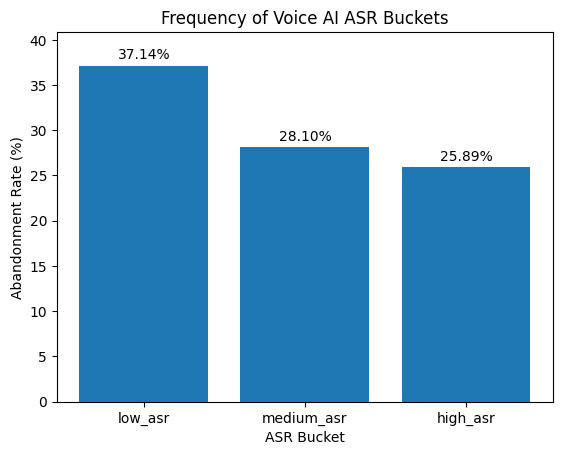

In [15]:
fig, ax = plt.subplots()

bars = ax.bar(
    asr_summary["asr_bucket"],
    asr_summary["abandonment_rate"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Frequency of Voice AI ASR Buckets")
ax.set_xlabel("ASR Bucket")
ax.set_ylabel("Abandonment Rate (%)")
ax.set_ylim(0, asr_summary["abandonment_rate"].max() * 1.1)

plt.show()


##### Results & Insight

Sessions with **low ASR confidence** exhibit the highest abandonment rate at approximately **37%**, compared to **28%** for medium ASR confidence and **25%** for high ASR confidence sessions.

This gradient demonstrates a clear relationship between speech recognition quality and session success. As ASR confidence improves, users are more likely to complete their interaction successfully. This confirms **speech recognition failure** as a primary friction point with direct impact on Voice AI effectiveness.

---

##### **Exploring Intent Misclassification as a Friction Point**

Intent-related friction is characterized by:

* Low `intent_confidence`
* Repeated clarification prompts
* Elevated misunderstanding rates

If intent misclassification materially increases user effort, it should be reflected in longer sessions, higher turn counts, or increased abandonment.


In [21]:
intent_df = (
    voice_ai_metrics_df
    .merge(
        voice_sessions_df[["session_id", "total_turns", "total_duration_sec", "final_outcome"]],
        on="session_id"
    )
)

intent_df["intent_bucket"] = pd.cut(
    intent_df["avg_intent_confidence"],
    bins=[0, 0.59999, 0.79999, 1.0],
    labels=["low_intent", "medium_intent", "high_intent"]
)

intent_summary = (
    intent_df
    .groupby("intent_bucket")
    .agg(
        avg_turns=("total_turns", "mean"),
        avg_duration=("total_duration_sec", "mean"),
        abandonment_rate=("final_outcome", lambda x: ((x == "abandoned").mean() * 100).round(2))
    )
    .sort_values("avg_duration", ascending=False)
    .reset_index()
)

intent_summary


C:\Users\USER\AppData\Local\Temp\ipykernel_26460\3807590211.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("intent_bucket")


,intent_bucket,avg_turns,avg_duration,abandonment_rate
0,low_intent,8.315217,135.652174,33.70
1,medium_intent,8.523610,121.727177,26.97
2,high_intent,8.748344,105.331126,29.80


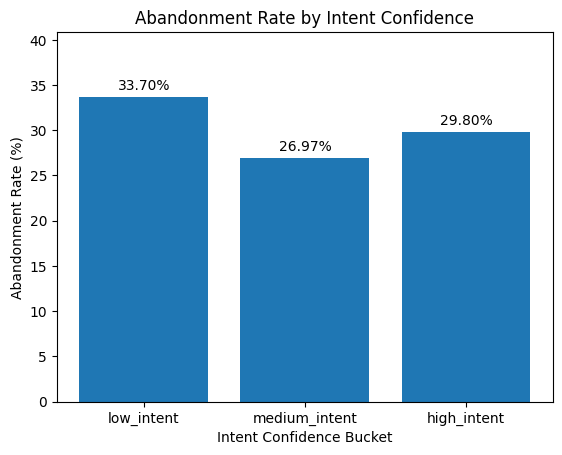

In [22]:
fig, ax = plt.subplots()

bars = ax.bar(
    intent_summary["intent_bucket"], 
    intent_summary["abandonment_rate"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Abandonment Rate by Intent Confidence")
ax.set_xlabel("Intent Confidence Bucket")
ax.set_ylabel("Abandonment Rate (%)")
ax.set_ylim(0, asr_summary["abandonment_rate"].max() * 1.1)

plt.show()

##### **Results & Insight**

Sessions with **low intent confidence** have the **longest average duration** and the **highest abandonment rate (33.7%)**, which indicates that users struggle to progress efficiently when the system misinterprets their intent.

While high-intent sessions show a moderately elevated abandonment rate (29.8%), they also have the **shortest average duration**. This suggests that abandonment in these cases may be driven by user choice rather than system friction.

Overall, intent misclassification emerges as a **secondary but meaningful friction point**, which affects efficiency and user persistence rather than outright failure.

---

#### **Failure to Recover from Errors**

Beyond the presence of errors themselves, another important friction point is the system’s ability to **recover after an error occurs**. A well-performing Voice AI should be able to guide users back on track following misunderstandings or silence.

To assess this, sessions with error signals will be evaluated based on their final outcomes.


In [24]:
recovery_outcome = (
    voice_ai_metrics_df
    .merge(voice_sessions_df[["session_id", "final_outcome"]], on="session_id")
    .groupby("recovery_success")
    .agg(
        completion_rate=("final_outcome", lambda x: ((x == "completed").mean() * 100).round(2)),
        abandonment_rate=("final_outcome", lambda x: ((x == "abandoned").mean() * 100).round(2))
    )
    .reset_index()
)

recovery_outcome


,recovery_success,completion_rate,abandonment_rate
0,no,54.28,28.81
1,yes,58.05,27.05


##### Results & Insight

Sessions where recovery fails have **lower completion rates** and **higher abandonment rates** compared to sessions where recovery is successful. This indicates that once errors occur, insufficient recovery mechanisms increase the likelihood of session failure.

While not all errors are avoidable, ineffective recovery amplifies their negative impact, which makes  **error recovery failure** a distinct friction point.

---

##### **Final Step: Ranking the Top Three Friction Points**

To justify the most impactful friction points, their associated abandonment rates will be compared.



In [40]:
#failure recovery summary
failure_recovery_summary = recovery_outcome.loc[recovery_outcome['recovery_success'] == 'no', ['recovery_success', 'abandonment_rate']]
failure_recovery_summary['recovery_category'] = failure_recovery_summary['recovery_success'].apply(lambda x: 'successful' if x == 'yes' else 'failed')
failure_recovery_summary = failure_recovery_summary[['recovery_category', 'abandonment_rate']]


#asr_summary
asr_summary = asr_summary.loc[asr_summary['asr_bucket'] == 'low_asr', ['asr_bucket', 'abandonment_rate']]
intent_summary = intent_summary.loc[intent_summary['intent_bucket'] == 'low_intent', ['intent_bucket', 'abandonment_rate']]

In [48]:
summary = pd.concat(
    [
        failure_recovery_summary.assign(friction_point="failure_recovery"),
        intent_summary.assign(friction_point="intent"),
        asr_summary.assign(friction_point="asr")
    ],
    ignore_index=True
)
ranked_friction_summary = summary[['friction_point', 'abandonment_rate']].sort_values('abandonment_rate', ascending=False).reset_index(drop=True)
ranked_friction_summary


,friction_point,abandonment_rate
0,asr,37.14
1,intent,33.70
2,failure_recovery,28.81


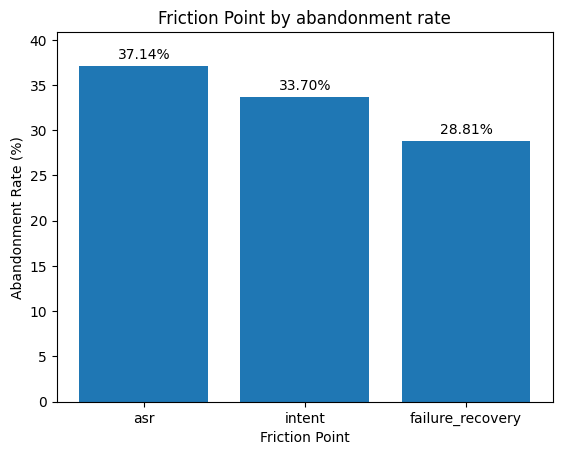

In [49]:
fig, ax = plt.subplots()

bars = ax.bar(
    ranked_friction_summary["friction_point"], 
    ranked_friction_summary["abandonment_rate"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Friction Point by abandonment rate")
ax.set_xlabel("Friction Point")
ax.set_ylabel("Abandonment Rate (%)")
ax.set_ylim(0, ranked_friction_summary["abandonment_rate"].max() * 1.1)

plt.show()

##### **Ranking Friction Points: Final Insight**

The results indicate that:

* **Speech recognition failure** is the most significant friction point, with an abandonment rate of **37.14%**
* **Intent misclassification** follows with an abandonment rate of **33.7%**
* **Failure to recover from errors** contributes an abandonment rate of **28.81%**

These findings show that friction in Voice AI interactions is primarily driven by **input understanding issues**, along with **limited recovery once errors occur**.


---

#### **3b. Compare Completion Rates**

i. Voice vs Non-Voice Channels

ii. Rural vs Urban Users

---

##### **Solution**

Before comparing completion rates across different user groups and channels, it is important to clearly define what **completion** means within this Voice AI system.

In this analysis, a session is considered **successfully completed** if **either** of the following conditions is met:

* The voice session ends with `final_outcome = 'completed'`, **or**
* The session is linked to at least one service application with `status = 'completed'`

This definition avoids undercounting successful interactions where the voice session ends, but the user proceeds to complete the service application downstream.

---

##### **Preparing the Data for Completion Analysis**

The **voice_sessions** table will be joined with the **applications** table to identify sessions that led to completed services.

However, it is important to note that a single session can be associated with **multiple applications**. A direct join would therefore create duplicate session rows and distort completion rate calculations.

To address this, applications are first **aggregated to the session level**. This ensures that:

* Each session appears only once
* We track whether **at least one application** linked to the session was completed

At the session level, the focus is on whether the Voice AI interaction successfully enabled service completion, not whether all linked applications were completed.



In [80]:
#aggregate applications at session level
applications_session_level_df = (
    applications_df
    .groupby("session_id")
    .agg(
        application_count=("application_id", "count"),
        any_completed_application=("status", lambda x: (x == "completed").any())
    )
    .reset_index()
)


We can now safely join back to sessions now

In [81]:
sessions_and_apps_status = voice_sessions_df.merge(
    applications_session_level_df, on="session_id", how="left"
)

In [82]:
sessions_and_apps_status

,session_id,user_id,channel,language,total_duration_sec,total_turns,final_outcome,transfer_reason,created_at,application_count,any_completed_application
0,S2000,U1303,voice,KINYARWANDA,173,11,abandoned,system,2025-02-17,NaN,NaN
1,S2001,U1449,voice,KINYARWANDA,150,4,completed,NaN,2025-02-20,NaN,NaN
2,S2002,U1453,voice,KINYARWANDA,128,11,transferred,NaN,2025-04-07,1.0,False
3,S2003,U1411,voice,KINYARWANDA,63,14,completed,NaN,2025-04-29,1.0,False
4,S2004,U1116,voice,KINYARWANDA,38,10,abandoned,NaN,2025-04-05,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...
1195,S3195,U1416,voice,KINYARWANDA,88,14,abandoned,NaN,2025-04-01,2.0,True
1196,S3196,U1219,voice,KINYARWANDA,48,12,completed,NaN,2025-03-13,2.0,True
1197,S3197,U1128,voice,KINYARWANDA,245,3,completed,NaN,2025-03-15,1.0,True
1198,S3198,U1007,voice,KINYARWANDA,25,10,completed,NaN,2025-03-13,1.0,False


In [ ]:
#define completion status properly
sessions_and_apps_status["completed"] = (
    (sessions_and_apps_status["final_outcome"] == "completed") |
    (sessions_and_apps_status["any_completed_application"])
)

In [84]:
sessions_and_apps_status

,session_id,user_id,channel,language,total_duration_sec,total_turns,final_outcome,transfer_reason,created_at,application_count,any_completed_application,completed
0,S2000,U1303,voice,KINYARWANDA,173,11,abandoned,system,2025-02-17,NaN,NaN,False
1,S2001,U1449,voice,KINYARWANDA,150,4,completed,NaN,2025-02-20,NaN,NaN,True
2,S2002,U1453,voice,KINYARWANDA,128,11,transferred,NaN,2025-04-07,1.0,False,False
3,S2003,U1411,voice,KINYARWANDA,63,14,completed,NaN,2025-04-29,1.0,False,True
4,S2004,U1116,voice,KINYARWANDA,38,10,abandoned,NaN,2025-04-05,1.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,S3195,U1416,voice,KINYARWANDA,88,14,abandoned,NaN,2025-04-01,2.0,True,True
1196,S3196,U1219,voice,KINYARWANDA,48,12,completed,NaN,2025-03-13,2.0,True,True
1197,S3197,U1128,voice,KINYARWANDA,245,3,completed,NaN,2025-03-15,1.0,True,True
1198,S3198,U1007,voice,KINYARWANDA,25,10,completed,NaN,2025-03-13,1.0,False,True


Going to the main question, to compare the completion rates across Voice vs Non-Voice channels. 

In [85]:
channel_completion = (
    sessions_and_apps_status
    .groupby("channel")
    .agg(
        total_sessions=("session_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

channel_completion["completion_rate"] = (
    round((channel_completion["completed_sessions"] /
    channel_completion["total_sessions"] * 100), 2)
)

channel_completion


,channel,total_sessions,completed_sessions,completion_rate
0,voice,1200,871,72.58


##### **Results & Insight**

The results show that **only one interaction channel is present in the dataset: Voice**. As a result, a direct comparison between voice and non-voice channels is not possible within the provided data.

The observed completion rate for the Voice channel is **72.58%**, which serves as the baseline completion performance of the Voice AI system

---

##### **3b(ii) Completion Rates: Rural vs Urban Users**

Since we have the session_application_status dataframe, we'll just merge this with the users df, so we can obtain user demographic information and get our results comparison.

In [146]:
applications_session_level_df

,session_id,application_count,any_completed_application
0,S2002,1,False
1,S2003,1,False
2,S2004,1,True
3,S2006,1,False
4,S2007,3,False
...,...,...,...
641,S3195,2,True
642,S3196,2,True
643,S3197,1,True
644,S3198,1,False


In [103]:
session_users = (
    sessions_and_apps_status
    .merge(
        users_df[["user_id", "region", "first_time_digital_user"]],
        on="user_id",
        how="left"
    )
)

region_completion = (
    session_users
    .groupby("region")
    .agg(
        total_sessions=("session_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

region_completion["completion_rate"] = (
    round(region_completion["completed_sessions"] /
    region_completion["total_sessions"] * 100, 2)
)

region_completion


,region,total_sessions,completed_sessions,completion_rate
0,rural,719,510,70.93
1,urban,481,361,75.05


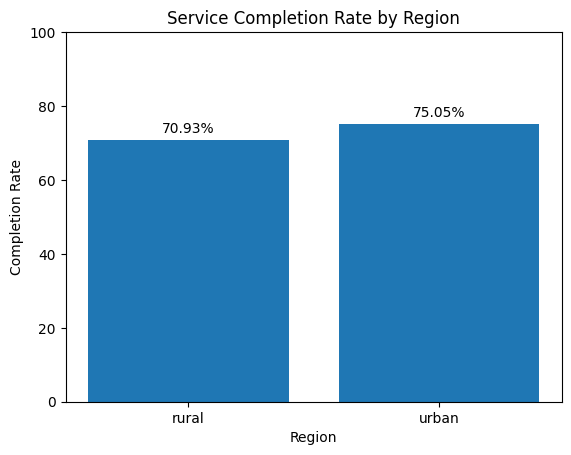

In [104]:
fig, ax = plt.subplots()

bars = ax.bar(
    region_completion["region"],
    region_completion["completion_rate"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Service Completion Rate by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Completion Rate")
ax.set_ylim(0, 100)

plt.show()


##### **Results & Insight**

The analysis shows that **urban users** have a higher completion rate (**75.05%**) compared to **rural users** (**70.93%**).

This gap suggests that while Voice AI improves access across regions, rural users may still face additional challenges such as connectivity quality, speech variability, or environmental noise, which can affect interaction success.

---


##### **(3c) Assess Whether First-Time Digital Users Perform Better with Voice AI Compared to Other Channels**

---

**SOLUTION**

The goal of this analysis is to assess whether Voice AI helps reduce friction specifically for **first-time digital users**, compared to more experienced users or traditional channels.

However, the session data provided contains **only Voice AI interactions**. As a result, a direct comparison between voice and non-voice channels is not possible.

Instead, the analysis will compare **first-time digital users** to **repeat digital users** within the Voice AI channel to understand whether Voice AI lowers entry barriers for users with limited prior digital experience.




In [116]:
first_time_comparison = (
    session_users
    .groupby("first_time_digital_user")
    .agg(
        total_sessions=("session_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

first_time_comparison["completion_rate"] = (
    round((first_time_comparison["completed_sessions"] /
    first_time_comparison["total_sessions"]) * 100, 2)
)

#assign no for repeated users, assign yes for first_time users
first_time_comparison['user_category'] = first_time_comparison['first_time_digital_user'].apply(lambda x: 'first_time_user' if x == 'yes' else 'repeated_user')

In [117]:
first_time_comparison

,first_time_digital_user,total_sessions,completed_sessions,completion_rate,user_category
0,no,693,499,72.01,repeated_user
1,yes,507,372,73.37,first_time_user


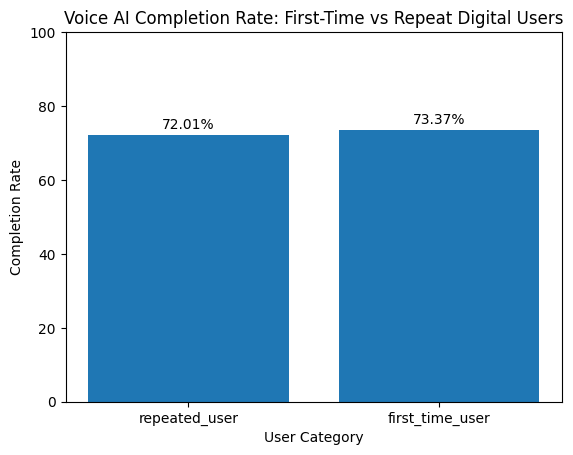

In [119]:
fig, ax = plt.subplots()

bars = ax.bar(
    first_time_comparison["user_category"],
    first_time_comparison["completion_rate"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_title("Voice AI Completion Rate: First-Time vs Repeat Digital Users")
ax.set_xlabel("User Category")
ax.set_ylabel("Completion Rate")
ax.set_ylim(0, 100)

plt.show()

---
##### **Measuring Performance and Effort**
User performance is evaluated using:

* **Completion rate**
* **Interaction effort**, measured by:

* Total session duration
* Total number of turns

Comparing these metrics will help to determine whether first-time users require significantly more effort to complete services.

In [ ]:
effort_comparison = (
    session_users
    .groupby("first_time_digital_user")
    .agg(
        avg_duration_sec=("total_duration_sec", "mean"),
        avg_turns=("total_turns", "mean")
    )
    .reset_index()
)

effort_comparison['user_category'] = effort_comparison['first_time_digital_user'].apply(lambda x: 'first_time_user' if x == 'yes' else 'repeated_user')


,first_time_digital_user,avg_duration_sec,avg_turns,user_category
0,no,123.658009,8.607504,repeated_user
1,yes,117.491124,8.445759,first_time_user


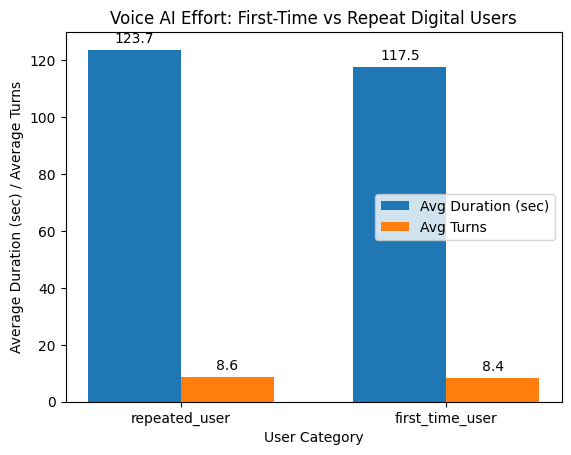

In [124]:
fig, ax = plt.subplots()

x = np.arange(len(effort_comparison["user_category"]))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    effort_comparison["avg_duration_sec"],
    width,
    label="Avg Duration (sec)"
)

bars2 = ax.bar(
    x + width/2,
    effort_comparison["avg_turns"],
    width,
    label="Avg Turns"
)

ax.bar_label(bars1, fmt="%.1f", padding=3)
ax.bar_label(bars2, fmt="%.1f", padding=3)

ax.set_title("Voice AI Effort: First-Time vs Repeat Digital Users")
ax.set_xlabel("User Category")
ax.set_ylabel("Average Duration (sec) / Average Turns")

ax.set_xticks(x)
ax.set_xticklabels(effort_comparison["user_category"])

ax.legend()
plt.show()

---

##### **Observation & Insight**

First-time digital users and repeat users show **very similar completion rates**, with first-time users achieving a completion rate of **73.37%** compared to **72.01%** for repeat users.

This indicates that Voice AI performs consistently across both groups. Notably, first-time users slightly outperform repeat users. This suggests that Voice AI effectively reduces the initial barriers typically faced by digitally inexperienced users.

Comparable completion rates and interaction effort across both groups indicate that Voice AI enables first-time digital users to access and complete public services without requiring additional effort, which supports its role as an accessibility-enhancing channel.

**THANK YOU !!!**
---